In [11]:
import typing as t
from pathlib import Path

from processing.orderbook import OrderBookDataset, OrderBookDataProcessor

ROOT_DIR: Path = Path.cwd().parent.parent
DATA_DIR: Path = ROOT_DIR / "data"
FILEPATH: Path = DATA_DIR / "round-0/day-1/prices_round_0_day_-1.csv"

NUM_QUOTES: t.Final[int] = 3

orderbook_data: OrderBookDataset = OrderBookDataset(FILEPATH)

In [12]:
products: t.List[str] = orderbook_data.products()
products

['TOMATOES', 'EMERALDS']

In [13]:
tomatoes: OrderBookDataProcessor = (
    orderbook_data
    .for_product("TOMATOES")
    .clean()
    .add_microstructure_features()
    .add_price_features()
    .add_depth_features()
    .build()
)
tomatoes

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,log_returns,future_log_returns,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64
0,4999,5,4998,15,null,null,5013,5,5014,15,null,null,5006.0,14,0.0,null,0.0001,10
100,5000,8,4998,21,null,null,5013,8,5014,21,null,null,5006.5,13,0.0,0.0001,0.0,16
200,5000,10,4999,20,null,null,5013,10,5015,20,null,null,5006.5,13,0.0,0.0,0.0001,20
300,5000,9,4999,21,null,null,5014,9,5015,21,null,null,5007.0,14,0.0,0.0001,0.0,18
400,5000,5,4999,20,null,null,5014,5,5015,20,null,null,5007.0,14,0.0,0.0,0.0,10
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,4955,5,4950,10,4948,23,4963,10,4964,23,null,null,4959.0,8,0.070423,0.000605,0.0,15
999600,4955,5,4949,6,4948,18,4963,6,4964,18,null,null,4959.0,8,0.09434,0.0,-0.000504,11
999700,4950,10,4948,16,null,null,4963,10,4964,16,null,null,4956.5,13,0.0,-0.000504,0.000202,20


In [14]:
emeralds: OrderBookDataProcessor = (
    orderbook_data
    .for_product("EMERALDS")
    .clean()
    .add_microstructure_features()
    .add_price_features()
    .add_depth_features()
    .build()
)
emeralds

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,log_returns,future_log_returns,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64
0,9992,14,9990,29,null,null,10008,14,10010,29,null,null,10000.0,16,0.0,null,0.0,28
100,9992,11,9990,22,null,null,10008,11,10010,22,null,null,10000.0,16,0.0,0.0,0.0,22
200,9992,15,9990,20,null,null,10008,15,10010,20,null,null,10000.0,16,0.0,0.0,0.0,30
300,9992,11,9990,29,null,null,10008,11,10010,29,null,null,10000.0,16,0.0,0.0,0.0,22
400,9992,12,9990,25,null,null,10008,12,10010,25,null,null,10000.0,16,0.0,0.0,0.0,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,9992,14,9990,29,null,null,10008,14,10010,29,null,null,10000.0,16,0.0,0.0,0.0,28
999600,9992,14,9990,28,null,null,10008,14,10010,28,null,null,10000.0,16,0.0,0.0,0.0,28
999700,9992,12,9990,26,null,null,10008,12,10010,26,null,null,10000.0,16,0.0,0.0,0.0,24


In [18]:
import polars as pl

joint: pl.DataFrame = pl.concat([
    tomatoes.select(pl.col("mid_price").alias("tomatoes_mid_price")),
    emeralds.select(pl.col("mid_price").alias("emeralds_mid_price"))
], how="horizontal")
joint

tomatoes_mid_price,emeralds_mid_price
f64,f64
5006.0,10000.0
5006.5,10000.0
5006.5,10000.0
5007.0,10000.0
5007.0,10000.0
…,…
4959.0,10000.0
4959.0,10000.0
4956.5,10000.0


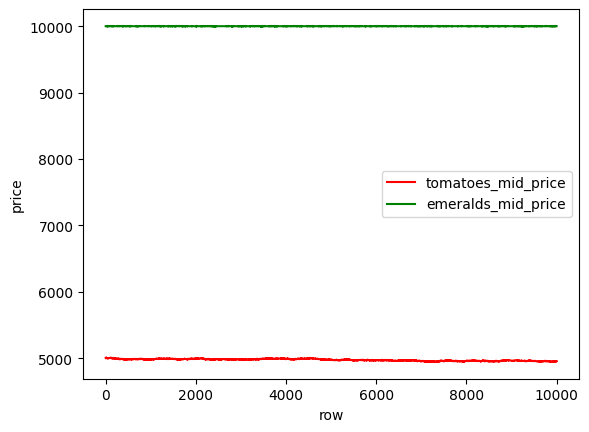

In [19]:
import matplotlib.pyplot as plt

rows = range(len(joint))

plt.plot(rows, joint["tomatoes_mid_price"], color="red", label="tomatoes_mid_price")
plt.plot(rows, joint["emeralds_mid_price"], color="green", label="emeralds_mid_price")

plt.legend()
plt.xlabel("row")
plt.ylabel("price")
plt.show()